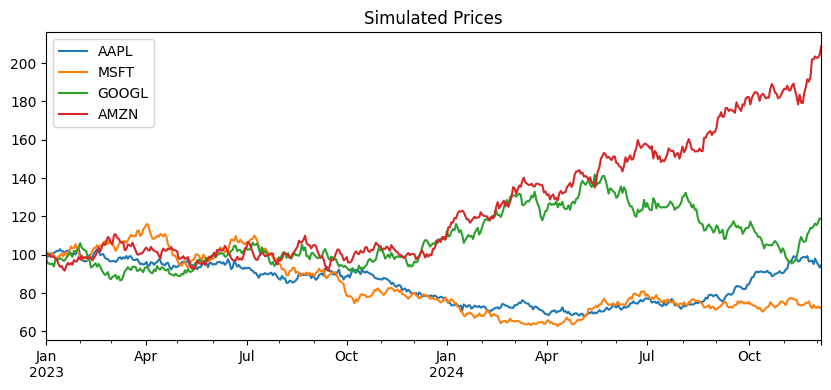

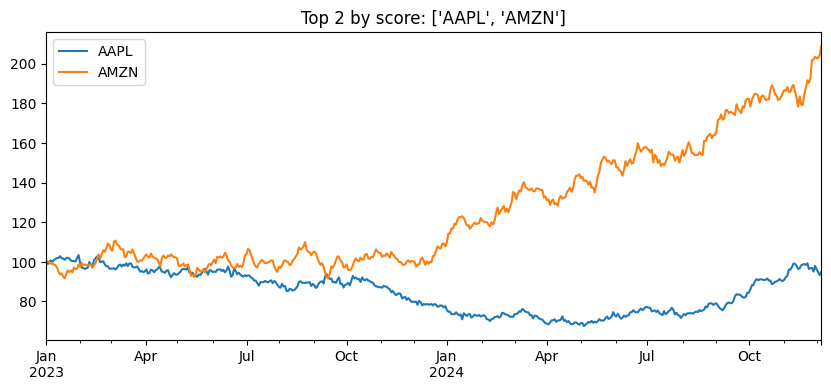

AAPL    18.341779
AMZN    14.594263
GOOGL    5.830624
MSFT    -2.434584
dtype: object
Handled: Not enough data: need >= 64 rows, got 40


In [11]:

import numpy as np
import pandas as pd
# np and pd for math
import matplotlib.pyplot as plt
# plt for ploting
from pathlib import Path
# for path generating

pd.options.display.float_format = "{:,.6f}".format
plt.rcParams["figure.figsize"] = (10,4)

# just to check if I can import from /src
import sys
from pathlib import Path
REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[2]
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

REPO_ROOT, SRC_PATH
# yes I can!
def simulate_prices(tickers, n=252*2, seed=1) -> pd.DataFrame:
    """
    Simulate strictly-positive daily prices (GBM-like).
    """
    rng = np.random.default_rng(seed)
    out = {}
    for t in tickers:
        mu  = 0.0005 + 0.0001*rng.standard_normal()
        sig = 0.012  + 0.002*abs(rng.standard_normal())
        out[t] = 100*np.cumprod(1 + mu + sig*rng.standard_normal(n))
    idx = pd.date_range("2023-01-02", periods=n, freq="B")
    return pd.DataFrame(out, index=idx)

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]
prices  = simulate_prices(TICKERS)
prices.head()
# now just using estimated values

prices.plot(title="Simulated Prices")
plt.show()

(prices.isna().sum(), len(prices))

# now defining the ranking class
class Ranking:
    """
    Momentum-over-Volatility ranking.

    momentum = price(t)/price(t-Lm) - 1
    vol      = stdev(returns over Lv)
    score    = momentum / vol  (higher is better)
    """
    def __init__(self, lookback_mom: int = 63, lookback_vol: int = 63):
        if lookback_mom < 2 or lookback_vol < 2:
            raise ValueError("Lookbacks must be >= 2.")
        self.Lm = int(lookback_mom)
        self.Lv = int(lookback_vol)

    def _validate(self, prices: pd.DataFrame):
        if not isinstance(prices, pd.DataFrame):
            raise TypeError("prices must be a pandas.DataFrame")
        needed = max(self.Lm, self.Lv) + 1
        if len(prices) < needed:
            raise ValueError(f"Not enough data: need >= {needed} rows, got {len(prices)}")
        if not isinstance(prices.index, pd.DatetimeIndex):
            raise TypeError("prices index must be a DatetimeIndex")
        if prices.isna().any().any():
            # allow NaNs but warn; last-row NaNs can break results
            print("[WARN] Prices contain NaNs. Ensure windows cover valid data.")

    def rank(self, prices: pd.DataFrame) -> pd.Series:
        self._validate(prices)

        # Momentum: use level prices
        mom = prices.iloc[-1] / prices.iloc[-self.Lm - 1] - 1

        # Volatility: std of returns over window
        rets = prices.pct_change().dropna()
        vol = rets.rolling(self.Lv).std().iloc[-1]

        # Guard against division by zero
        vol = vol.replace(0, pd.NA)

        score = (mom / vol).dropna()
        return score.sort_values(ascending=False)
# Why these choices?

#Level-price momentum is intuitive and matches many industry implementations.

#Equal windows (63/63) keep it simple.

#We sort descending so “best first” is clear.

r = Ranking(lookback_mom=63, lookback_vol=63)
scores = r.rank(prices)
scores
# just ran the rank

Lm, Lv = r.Lm, r.Lv
mom = prices.iloc[-1] / prices.iloc[-Lm-1] - 1
rets = prices.pct_change().dropna()
vol = rets.rolling(Lv).std().iloc[-1]

diagnostic = pd.DataFrame({"momentum": mom, "volatility": vol, "score": scores})
diagnostic
# understanding what drives each score

diagnostic.sort_values("momentum", ascending=False)

top2 = list(scores.index[:2])
prices[top2].plot(title=f"Top 2 by score: {top2}")
plt.show()
#plot top 2 to understand the behavior

# 1) What if one ticker is very flat (near-zero vol)?
flat = prices.copy()
flat["FLAT"] = 100.0  # constant price (extreme case)
try:
    print(Ranking(63,63).rank(flat).head())
except Exception as e:
    print("Handled:", e)

# 2) Not enough data for the chosen windows
try:
    short = prices.tail(40)
    Ranking(63,63).rank(short)
except Exception as e:
    print("Handled:", e)

# Exporting scores to CSV
OUTDIR = Path.cwd()  # notebook's working dir (under src/playground)
out_csv = OUTDIR / "ranking_scores.csv"
scores.to_csv(out_csv, header=["score"])
out_csv, out_csv.exists()

#Swap simulator for your real data
def load_prices_from_utils(tickers):
    # Example signature: adjust to your team’s function
    # from utils.prices.get import get_close_prices
    # return get_close_prices(tickers, start="2018-01-01")
    raise NotImplementedError("Plug your real loader here")

# prices = load_prices_from_utils(TICKERS)
# scores = Ranking(63,63).rank(prices)




